In [26]:
from config_feature_test import FEATURES, LABEL
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Trainings- und Testdaten laden
train_df = pd.read_parquet('train_block.parquet')
test_df = pd.read_parquet('test_block.parquet')

In [27]:
# Label umwandeln: 'attack' → 1, 'benign' → 0
train_df[LABEL] = train_df[LABEL].map({'attack': 1, 'benign': 0})
test_df[LABEL] = test_df[LABEL].map({'attack': 1, 'benign': 0})

# Features und Label auswählen
X_train = train_df[FEATURES]
y_train = train_df[LABEL]
X_test = test_df[FEATURES]
y_test = test_df[LABEL]

# Features skalieren (Scaler auf Trainingsdaten fitten, auf beide anwenden)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
test_df.head()

,timestamp,ase_spec,br_immed_spec,br_indirect_spec,br_mis_pred,br_pred,br_return_spec,branch-load-misses,branch-loads,branch-misses,...,writeback_writeback_single_inode,writeback_writeback_single_inode_start,writeback_writeback_start,writeback_writeback_wait,writeback_writeback_wait_iff_congested,writeback_writeback_wake_background,writeback_writeback_write_inode,writeback_writeback_written,attack,Label
0,2025-07-22T19:53:10,847.0,540525.0,115706.0,15452.0,656131.0,96680.0,15185.0,651088.0,14893.0,...,549617,549617,1336098,0,0,210,472963,1336098,benign,0
1,2025-07-22T19:53:20,808.0,527069.0,112884.0,14933.0,639855.0,94312.0,14941.0,640294.0,14456.0,...,549628,549628,1336113,0,0,210,472972,1336113,benign,0
2,2025-07-22T19:53:30,844.0,537613.0,115032.0,15021.0,652547.0,96070.0,14841.0,642126.0,15904.0,...,549640,549640,1336127,0,0,210,472982,1336127,benign,0
3,2025-07-22T19:53:40,879.0,530950.0,113144.0,14686.0,643996.0,94525.0,14882.0,640138.0,15161.0,...,549650,549650,1336139,0,0,210,472991,1336139,benign,0
4,2025-07-22T19:53:50,872.0,533494.0,113819.0,14967.0,647215.0,95060.0,14997.0,650649.0,14580.0,...,549654,549654,1336149,0,0,210,472995,1336149,benign,0


In [31]:
import numpy as np

def create_sequences(X, y, window_size=10):
    X_seq = []
    y_seq = []
    for i in range(len(X) - window_size + 1):
        label_window = y[i:i+window_size]
        
        # Only keep sequences where all labels in the window are the same
        if np.all(label_window == label_window[0]):
            X_seq.append(X[i:i+window_size])     # Add sequence window of features
            y_seq.append(label_window[0])        # Add corresponding consistent label
    return np.array(X_seq), np.array(y_seq)

In [30]:
# Statt nur homogene Labels:
def create_sequences_mixed(X, y, window_size=10):
    X_seq = []
    y_seq = []
    for i in range(len(X) - window_size + 1):
        label_window = y[i:i+window_size]
        X_seq.append(X[i:i+window_size])
        # Attack, wenn mindestens ein Angriff im Fenster ist
        y_seq.append(1 if np.any(label_window == 1) else 0)
    return np.array(X_seq), np.array(y_seq)


In [32]:
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train.values, window_size=10)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test.values, window_size=10)

print(X_train_seq.shape)  # (Anzahl Fenster, 10, Anzahl Features)
print(y_train_seq.shape)  # (Anzahl Fenster,)


(4586, 10, 20)
(4586,)


In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Function to create a stacked LSTM model
def create_lstm_model(num_features):
    model = Sequential([
        # First LSTM layer (returns full sequences for stacking)
        LSTM(30, input_shape=(10, num_features), return_sequences=True),
        Dropout(0.2),  # Dropout to prevent overfitting
        # Second LSTM layer (only returns final output)
        LSTM(15),
        Dropout(0.2),  # Additional regularization
        # Output layer for binary classification
        Dense(1, activation='sigmoid')
    ])
    
    # Compile model with binary crossentropy loss and accuracy metric
    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

# Create model with number of selected input features
model = create_lstm_model(len(FEATURES))

# Print model summary
model.summary()

# Print number of selected features
print(len(FEATURES))

/home/yannic/Desktop/Uni/Semester8_Regensburg/Bachelorarbeit/bachelor/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 10, 30)         │         6,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 10, 30)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 15)             │         2,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,896 (34.75 KB)

 Trainable params: 8,896 (34.75 KB)

 Non-trainable params: 0 (0.00 B)

20


In [34]:
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=25,
    batch_size=32,
    validation_data=(X_test_seq, y_test_seq),
    verbose=1
)

Epoch 1/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8574 - loss: 0.3441 - val_accuracy: 0.9015 - val_loss: 0.3296
Epoch 2/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9766 - loss: 0.0630 - val_accuracy: 0.9020 - val_loss: 0.4367
Epoch 3/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9850 - loss: 0.0359 - val_accuracy: 0.9057 - val_loss: 0.3284
Epoch 4/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9879 - loss: 0.0323 - val_accuracy: 0.9067 - val_loss: 0.3914
Epoch 5/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9886 - loss: 0.0287 - val_accuracy: 0.9057 - val_loss: 0.2210
Epoch 6/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9893 - loss: 0.0259 - val_accuracy: 0.9057 - val_loss: 0.3223
Epoch 7/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9893 - loss: 0.0220 - val_accuracy: 0.9124 - val_loss: 0.3372
Epoch 8/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9888 - loss: 0.0280 - val_accuracy: 0.

In [35]:
from sklearn.metrics import accuracy_score, classification_report

# 1. Vorhersage für Sequenzdaten
y_pred_prob = model.predict(X_test_seq)

# 2. Wahrscheinlichkeiten zu Klassenlabels
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# 3. Genauigkeit und Klassifikationsbericht (jetzt gleiche Länge!)
accuracy = accuracy_score(y_test_seq, y_pred)
report = classification_report(y_test_seq, y_pred)

# 4. Ausgabe
print(f"Genauigkeit: {accuracy:.4f}")
print(report)


61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Genauigkeit: 0.9108
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      1676
           1       0.76      0.46      0.58       253

    accuracy                           0.91      1929
   macro avg       0.84      0.72      0.76      1929
weighted avg       0.90      0.91      0.90      1929



61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[[1640   36]
 [ 136  117]]


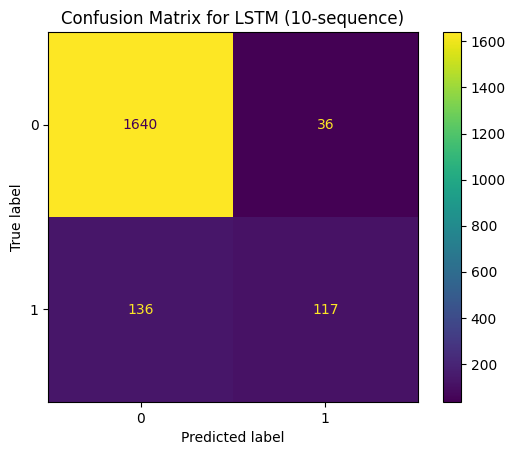

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os

# 1. Make predictions for the test data – NOTE: use _seq!
y_pred_seq = (model.predict(X_test_seq) > 0.5).astype(int).flatten()

# 2. Compute the confusion matrix – the lengths match now!
cm = confusion_matrix(y_test_seq, y_pred_seq)

# 3. Print the confusion matrix as numbers
print(cm)

# 4. Display the confusion matrix as a graphic
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix for LSTM (10-sequence)')

output_dir = "/home/yannic/Desktop/Uni/Semester8_Regensburg/Bachelorarbeit/graffics_for_BA/feature_plots"
filename = f"confusion_matrix.png"
filepath = os.path.join(output_dir, filename)
plt.savefig(filepath, dpi=300)
plt.show()


In [37]:
import pandas as pd
import numpy as np

window_size = 10
attack_array = test_df["attack"].values
y_array = y_test.values

# Select attack type of the first row in windows with uniform labels
attack_seq = np.array([
    attack_array[i]
    for i in range(len(attack_array) - window_size + 1)
    if np.all(y_array[i:i+window_size] == y_array[i])
])

# Create DataFrame combining prediction results and attack types
df = pd.DataFrame({
    "y_true": y_test_seq,
    "y_pred": y_pred_seq,
    "attack": attack_seq
})

# Filter: misclassified attacks (true=1, pred=0)
misclassified = df[(df["y_true"] == 1) & (df["y_pred"] == 0)]

# Count misclassified and total attacks
misclassified_counts = misclassified["attack"].value_counts()
total_counts = df[df["y_true"] == 1]["attack"].value_counts()

# Combine into single table
summary = pd.DataFrame({
    "misclassified": misclassified_counts,
    "total": total_counts
}).fillna(0).astype(int)

print(summary.sort_values("misclassified", ascending=False))

                  misclassified  total
attack                                
osfingerprinting             48     51
slowloris                    35     37
aggressivescan               30     51
portscan                     23     51
synonymousflood               0     60
tcpflood                      0      3


61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


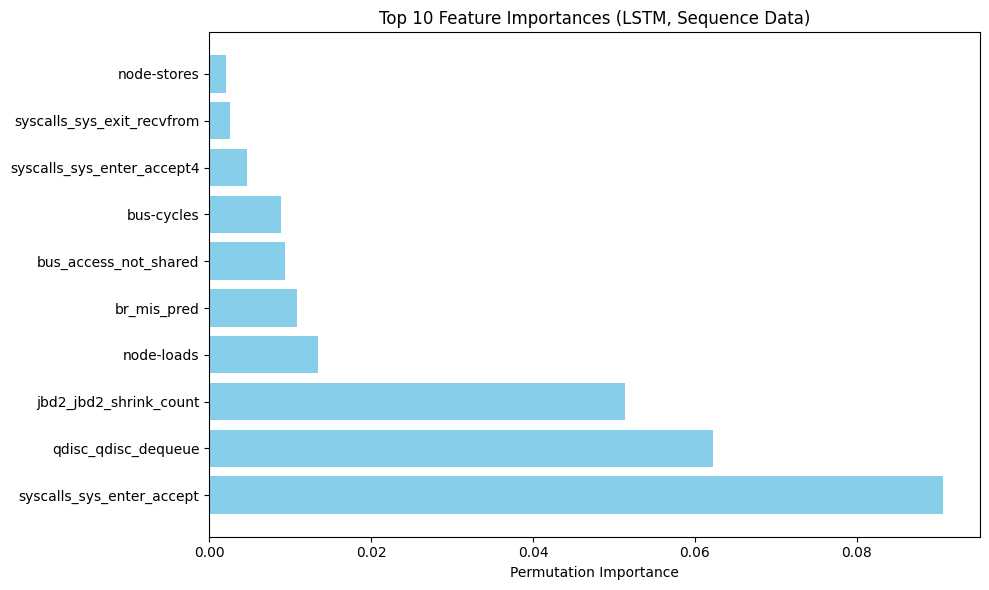

In [38]:
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Assumption: model, X_test_seq, y_test_seq, FEATURES are already defined

# 1. Baseline accuracy for the sequenced test set
y_pred_seq = model.predict(X_test_seq)
original_acc = accuracy_score(y_test_seq, (y_pred_seq > 0.5).astype(int))

feature_importances = []
for i in range(X_test_seq.shape[2]):
    X_test_perm = X_test_seq.copy()
    # Shuffle the i-th feature across all windows and time steps
    np.random.shuffle(X_test_perm[:, :, i])
    y_pred_perm = model.predict(X_test_perm)
    perm_acc = accuracy_score(y_test_seq, (y_pred_perm > 0.5).astype(int))
    feature_importances.append(original_acc - perm_acc)

# 2. Find top 10 features
indices_top10 = np.argsort(feature_importances)[10:][::-1]
top10_features = [FEATURES[i] for i in indices_top10]
top10_importances = [feature_importances[i] for i in indices_top10]

# 3. Draw bar chart for top 10 features
plt.figure(figsize=(10, 6))
plt.barh(top10_features, top10_importances, color='skyblue')
plt.xlabel('Permutation Importance')
plt.title('Top 10 Feature Importances (LSTM, Sequence Data)')
plt.tight_layout()
output_dir = "/home/yannic/Desktop/Uni/Semester8_Regensburg/Bachelorarbeit/graffics_for_BA/feature_plots"
filename = f"feature_importances_lstm.png"
filepath = os.path.join(output_dir, filename)
plt.savefig(filepath, dpi=300)
plt.show()


In [39]:
print(top20_features)


NameError: name 'top20_features' is not defined

In [40]:
from tensorflow.keras.models import load_model
import joblib

model.save('lstm_model_20events.h5')
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

In [41]:
print(scaler.feature_names_in_)


['syscalls_sys_exit_recvfrom' 'bus_access_not_shared'
 'tcp_tcp_retransmit_skb' 'jbd2_jbd2_checkpoint_stats' 'l2d_cache_wb'
 'jbd2_jbd2_shrink_count' 'qdisc_qdisc_dequeue'
 'syscalls_sys_enter_accept4' 'syscalls_sys_enter_accept' 'node-loads'
 'bus-cycles' 'iTLB-load-misses' 'dTLB-load-misses' 'node-stores'
 'l1d_cache_wb_clean' 'syscalls_sys_enter_fchmod' 'dp_spec'
 'l2d_cache_refill_rd' 'br_mis_pred' 'mem_access']
